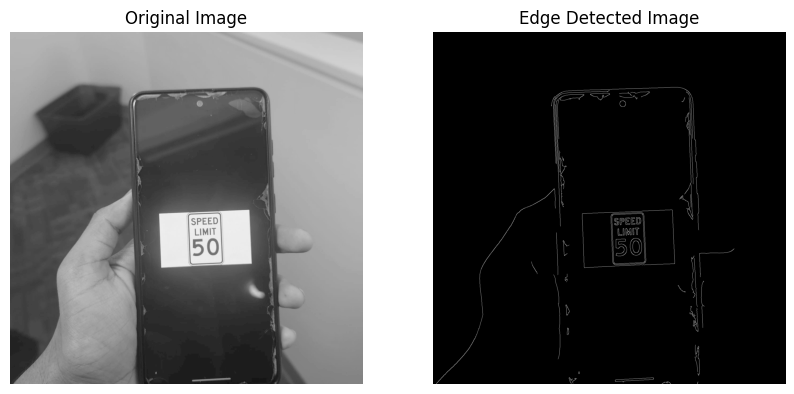

In [10]:
image_path = r"C:\Users\nishi\Downloads\cpen 391 srcipts\SignSafety\jupyter_scripts\speed.png"

# Step 1: Import necessary libraries
import cv2
import matplotlib.pyplot as plt
# from google.colab import files
import numpy as np
# Set up pytesseract executable path (update this for your system)
# pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'


# Step 2: Upload an image
# uploaded = files.upload()

# Step 3: Read the uploaded image
# image_path = next(iter(uploaded))
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Step 4: Apply Gaussian Blur to reduce noise
blurred_image = cv2.GaussianBlur(image, (5, 5), 1.4)

# Step 5: Apply Canny edge detector
edges = cv2.Canny(blurred_image, 50, 150)

# Step 6: Display the original image and the edge-detected image
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(image, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Edge Detected Image')
plt.imshow(edges, cmap='gray')
plt.axis('off')

plt.show()

In [28]:
import cv2
import numpy as np

# Use a raw string to avoid escape character issues
image_path = r"C:\Users\nishi\Downloads\cpen 391 srcipts\SignSafety\jupyter_scripts\rgb_image.png"
image = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)

# Check if the image was loaded successfully
if image is None:
    print(f"Error: Unable to load image at {image_path}")
else:
    # Convert the image to HSV color space
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    
    # Define range for red color in HSV
    lower_red1 = np.array([0, 100, 60])
    upper_red1 = np.array([10, 255, 255])
    lower_red2 = np.array([170, 100, 50])
    upper_red2 = np.array([180, 255, 255])
    
    # Create masks for red color ranges
    mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
    mask2 = cv2.inRange(hsv, lower_red2, upper_red2)
    red_mask = cv2.bitwise_or(mask1, mask2)
    
    # Apply the mask to the original image
    red_highlighted = cv2.bitwise_and(image, image, mask=red_mask)
    
    # Optional: Find contours and draw bounding boxes around red areas
    contours, _ = cv2.findContours(red_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        if w > 10 and h > 10:  # Filter out small regions
            cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 2)  # Green bounding box
    
    # Display the original image with bounding boxes
    cv2.imshow("Detected Red Regions", image)
    
    # Display the red-highlighted image
    cv2.imshow("Red Highlighted", red_highlighted)
    cv2.waitKey(0)
    cv2.destroyAllWindows()
